[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jdsanch1/simrc/blob/master/01.%20Parte%201/07.%20Clase%207/07Class%20NB.ipynb)

In [ ]:
!pip install -q yfinance pandas numpy matplotlib seaborn scipy scikit-learn statsmodels

# Clase 7:	Simulación de riesgo de mercado

[Juan Diego Sánchez Torres](https://www.researchgate.net/profile/Juan_Diego_Sanchez_Torres), 

*Profesor*, [MAF ITESO](http://maf.iteso.mx/web/general/detalle?group_id=5858156)

+ Departamento de Matemáticas y Física
+ dsanchez@iteso.mx
+ Tel. 3669-34-34 Ext. 3069
+ Oficina: Cubículo 4, Edificio J, 2do piso

# 1. Motivación

En primer lugar, para poder bajar precios y información sobre opciones de Yahoo, es necesario cargar algunos paquetes de Python. En este caso, el paquete principal será Pandas. También, se usarán el Scipy y el Numpy para las matemáticas necesarias y, el Matplotlib y el Seaborn para hacer gráficos de las series de datos.

In [19]:
#importar los paquetes que se van a usar
import pandas as pd
import yfinance as yf
import numpy as np
from sklearn.neighbors import KernelDensity
import datetime
from datetime import datetime, timedelta
import scipy.stats as stats
import scipy as sp
import scipy.optimize as optimize
import scipy.cluster.hierarchy as hac
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
#algunas opciones para Python
pd.set_option('display.notebook_repr_html', True)
pd.set_option('display.max_columns', 6)
pd.set_option('display.max_rows', 10)
pd.set_option('display.width', 78)
pd.set_option('precision', 3)

In [2]:
def get_historical_closes(tickers, start_date, end_date):
    """Descarga precios de cierre ajustados usando yfinance."""
    import yfinance as yf
    import pandas as pd
    data = yf.download(tickers, start=start_date, end=end_date,
                       auto_adjust=True, progress=False)
    if isinstance(data.columns, pd.MultiIndex):
        closes = data["Close"]
    else:
        closes = data[["Close"]]
        closes.columns = [tickers] if isinstance(tickers, str) else list(tickers)
    closes.index.name = "Date"
    return closes.dropna()

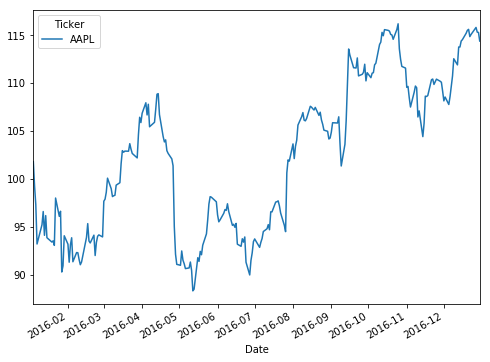

In [3]:
data=get_historical_closes(['AAPL'], '2025-01-01', '2025-03-27')
data.plot(figsize=(8,6));

In [4]:
aapl = web.Options('AAPL', 'yahoo')
appl_opt = aapl.get_all_data().reset_index()
appl_opt

,Strike,Expiry,Type,...,Quote_Time,Last_Trade_Date,JSON
0,2.5,2017-09-15,call,...,2017-09-01 20:00:00,2017-09-02 03:47:35,"{'lastPrice': 161.55, 'openInterest': 20, 'cha..."
1,2.5,2017-11-17,call,...,2017-09-01 20:00:00,2017-08-09 18:58:30,"{'lastPrice': 158.14, 'openInterest': 0, 'chan..."
2,2.5,2018-01-19,call,...,2017-09-01 20:00:00,2017-08-09 19:07:11,"{'lastPrice': 158.13, 'openInterest': 0, 'chan..."
3,2.5,2018-01-19,put,...,2017-09-01 20:00:00,2017-08-11 21:11:33,"{'lastPrice': 0.02, 'openInterest': 2, 'change..."
4,5.0,2017-09-15,call,...,2017-09-01 20:00:00,2017-08-30 19:58:16,"{'lastPrice': 158.2, 'openInterest': 70, 'chan..."
...,...,...,...,...,...,...,...
1084,305.0,2017-09-15,put,...,2017-09-01 20:00:00,2017-08-30 19:51:13,"{'lastPrice': 141.75, 'openInterest': 0, 'chan..."
1085,305.0,2018-01-19,call,...,2017-09-01 20:00:00,2017-08-29 19:56:55,"{'lastPrice': 0.01, 'openInterest': 22, 'chang..."
1086,305.0,2018-01-19,put,...,2017-09-01 20:00:00,2017-07-24 18:37:53,"{'lastPrice': 153.75, 'openInterest': 61, 'cha..."
1087,305.0,2018-04-20,call,...,2017-09-01 20:00:00,2017-08-26 03:51:17,"{'lastPrice': 0.11, 'openInterest': 140, 'chan..."


In [5]:
def calc_daily_returns(closes):
    return np.log(closes/closes.shift(1))[1:]

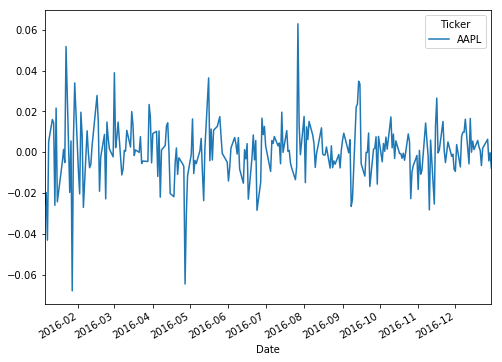

In [6]:
daily_returns=calc_daily_returns(data)
daily_returns.plot(figsize=(8,6));

# 2. Modelo normal para los rendimientos

In [7]:
mu=daily_returns.mean().AAPL
sigma=daily_returns.std().AAPL
ndays = 360
ntraj=10
dates=pd.date_range('20170101',periods=ndays)
simret = pd.DataFrame(sigma*np.random.randn(ndays,ntraj)+mu,index=dates)
simret

,0,1,2,...,7,8,9
2017-01-01,-0.006,0.019,1.369e-02,...,2.390e-02,0.025,0.009
2017-01-02,0.028,0.016,2.906e-02,...,-5.056e-03,0.020,0.032
2017-01-03,-0.002,0.010,-1.244e-02,...,1.091e-02,-0.013,0.008
2017-01-04,0.002,0.023,8.434e-03,...,2.166e-02,-0.015,0.004
2017-01-05,-0.015,0.010,-2.468e-02,...,7.567e-03,0.027,-0.016
...,...,...,...,...,...,...,...
2017-12-22,0.003,-0.031,-1.245e-04,...,-7.482e-03,0.013,0.005
2017-12-23,-0.010,-0.016,4.881e-04,...,2.367e-02,0.019,-0.014
2017-12-24,0.009,0.011,-8.751e-03,...,2.254e-03,-0.003,0.011
2017-12-25,0.007,-0.003,1.246e-02,...,2.407e-04,-0.002,-0.014


In [8]:
simdata=(data.loc['2025-03-27',:].AAPL)*np.exp(simret.cumsum())
simdata

,0,1,2,...,7,8,9
2017-01-01,113.660,116.588,115.973,...,117.164,117.242,115.445
2017-01-02,116.887,118.514,119.393,...,116.573,119.629,119.185
2017-01-03,116.656,119.655,117.917,...,117.852,118.110,120.096
2017-01-04,116.852,122.479,118.915,...,120.432,116.406,120.638
2017-01-05,115.136,123.655,116.016,...,121.347,119.634,118.782
...,...,...,...,...,...,...,...
2017-12-22,174.164,117.708,118.162,...,140.272,187.224,175.794
2017-12-23,172.379,115.880,118.220,...,143.632,190.876,173.413
2017-12-24,173.888,117.139,117.190,...,143.956,190.295,175.274
2017-12-25,175.084,116.828,118.659,...,143.990,189.984,172.839


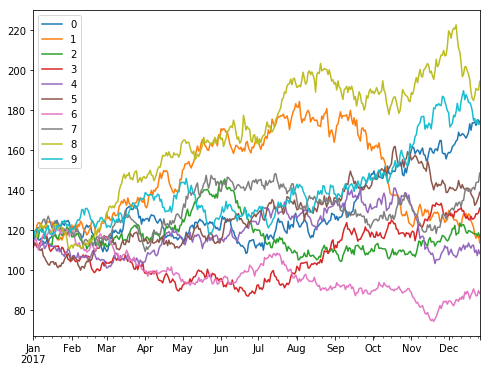

In [9]:
simdata.plot(figsize=(8,6));

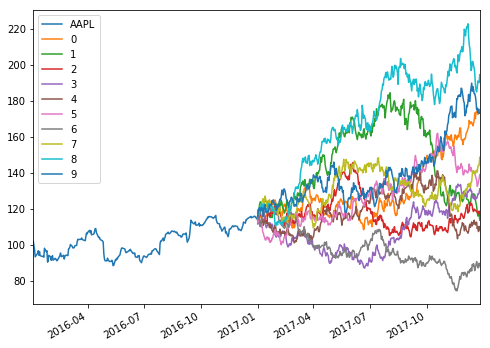

In [10]:
pd.concat([data,simdata]).plot(figsize=(8,6));

# 3. Simulación usando el histograma de los rendimientos

In [17]:
ndays = 360
ntraj=10
#
values,indices=np.histogram(daily_returns,bins=250)
values=values.astype(np.float32)
weights=values/np.sum(values)
ret=np.random.choice(indices[1:],ndays*ntraj,p=weights)
#
dates=pd.date_range('20170101',periods=ndays)
simret = pd.DataFrame(ret.reshape((ndays,ntraj)),index=dates)
simret

,0,1,2,...,7,8,9
2017-01-01,2.200e-03,-1.141e-02,-4.177e-04,...,1.267e-02,-0.006,1.060e-04
2017-01-02,-9.413e-04,9.007e-03,-1.141e-02,...,-4.083e-03,0.014,-1.037e-02
2017-01-03,6.296e-04,1.110e-02,-2.503e-02,...,-4.177e-04,0.015,-2.398e-02
2017-01-04,4.295e-03,-2.241e-02,-4.607e-03,...,-1.874e-02,-0.001,-1.989e-03
2017-01-05,6.389e-03,5.866e-03,1.267e-02,...,-3.079e-02,0.010,3.771e-03
...,...,...,...,...,...,...,...
2017-12-22,9.007e-03,1.060e-04,6.296e-04,...,5.342e-03,0.002,7.437e-03
2017-12-23,6.296e-04,1.153e-03,7.960e-03,...,2.200e-03,-0.005,1.005e-02
2017-12-24,-7.748e-03,-6.701e-03,7.960e-03,...,-1.560e-02,0.008,3.362e-02
2017-12-25,3.414e-02,4.295e-03,-7.748e-03,...,9.007e-03,0.052,-2.241e-02


In [18]:
simdata=(data.loc['2025-03-27',:].AAPL)*np.exp(simret.cumsum())
simdata

,0,1,2,...,7,8,9
2017-01-01,114.649,113.098,114.349,...,115.856,113.752,114.409
2017-01-02,114.541,114.122,113.051,...,115.384,115.323,113.229
2017-01-03,114.613,115.396,110.257,...,115.335,117.100,110.546
2017-01-04,115.106,112.839,109.750,...,113.194,116.929,110.326
2017-01-05,115.844,113.502,111.150,...,109.762,118.110,110.743
...,...,...,...,...,...,...,...
2017-12-22,113.089,195.870,135.551,...,230.993,128.905,140.170
2017-12-23,113.160,196.096,136.634,...,231.502,128.246,141.587
2017-12-24,112.286,194.786,137.726,...,227.918,129.271,146.427
2017-12-25,116.186,195.624,136.663,...,229.981,136.163,143.182


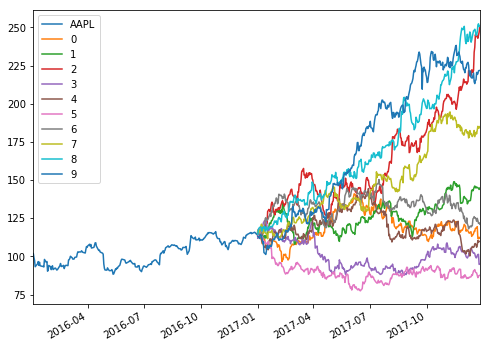

In [16]:
pd.concat([data,simdata]).plot(figsize=(8,6));

In [36]:
kde = KernelDensity(kernel='gaussian', bandwidth=0.001).fit(daily_returns)
ndays = 360
ntraj=10
#
ret=kde.sample(n_samples=ndays*ntraj, random_state=None)
#
dates=pd.date_range('20170101',periods=ndays)
simret = pd.DataFrame(ret.reshape((ndays,ntraj)),index=dates)
simret

,0,1,2,...,7,8,9
2017-01-01,0.015,0.011,3.967e-03,...,7.900e-03,0.009,1.710e-02
2017-01-02,-0.006,0.021,3.549e-03,...,3.563e-04,-0.006,2.921e-03
2017-01-03,-0.005,0.004,5.369e-05,...,1.686e-02,0.027,-7.424e-03
2017-01-04,0.005,0.027,1.572e-03,...,5.367e-03,0.002,-1.370e-02
2017-01-05,0.003,-0.025,1.154e-02,...,8.427e-03,0.008,-2.410e-02
...,...,...,...,...,...,...,...
2017-12-22,0.021,-0.026,-1.056e-03,...,-6.890e-03,-0.009,-1.813e-02
2017-12-23,-0.007,-0.009,1.628e-02,...,1.510e-03,-0.004,-3.138e-04
2017-12-24,0.009,-0.007,3.610e-04,...,6.288e-02,0.002,-8.978e-03
2017-12-25,-0.004,-0.005,-1.765e-02,...,1.102e-03,-0.066,8.271e-03


In [37]:
simdata=(data.loc['2025-03-27',:].AAPL)*np.exp(simret.cumsum())
simdata

,0,1,2,...,7,8,9
2017-01-01,116.121,115.648,114.852,...,115.304,115.469,116.370
2017-01-02,115.433,118.114,115.260,...,115.345,114.757,116.711
2017-01-03,114.857,118.624,115.266,...,117.307,117.918,115.847
2017-01-04,115.481,121.831,115.447,...,117.938,118.197,114.271
2017-01-05,115.782,118.797,116.788,...,118.936,119.189,111.550
...,...,...,...,...,...,...,...
2017-12-22,154.958,157.732,190.061,...,171.371,150.035,113.496
2017-12-23,153.801,156.253,193.180,...,171.630,149.475,113.460
2017-12-24,155.235,155.087,193.250,...,182.770,149.758,112.446
2017-12-25,154.562,154.360,189.870,...,182.971,140.206,113.380


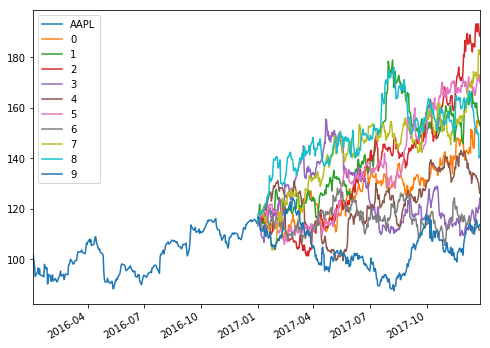

In [38]:
pd.concat([data,simdata]).plot(figsize=(8,6));